# End-to-End Sales Forecasting & Demand Intelligence System

### Internship Project

---

## Project Objective

The objective of this project is to analyze historical retail sales data, forecast future demand, detect unusual sales patterns, segment products based on demand characteristics, and develop an interactive business dashboard for decision-making.

## Table of Contents

1. Project Introduction

2. Task 1 – Data Loading and Exploratory Data Analysis

3. Task 2 – Time Series Analysis and Decomposition

4. Task 3 – Sales Forecasting

5. Task 4 – Category and Region Forecasting

6. Task 5 – Anomaly Detection

7. Task 6 – Product Demand Segmentation

8. Task 7 – Streamlit Dashboard

9. Task 8 – Executive Summary

10. Conclusion

# Project Introduction

Retail businesses generate large volumes of transactional sales data every day. Analyzing this data helps organizations understand customer purchasing behavior, identify seasonal demand patterns, forecast future sales, and optimize inventory planning.

In this project, the Superstore Sales dataset is analyzed to develop an end-to-end sales forecasting and demand intelligence system. The project combines exploratory data analysis, time series forecasting, anomaly detection, product demand segmentation, and an interactive Streamlit dashboard to generate business insights that support informed decision-making.

# Dataset Description

The project uses the Superstore Sales dataset containing historical retail transactions from 2015 to 2018.

The dataset includes information such as:

- Order Date
- Ship Date
- Product Category
- Sub-Category
- Region
- Sales
- Quantity
- Discount
- Profit

These attributes are used to analyze historical sales performance, identify demand patterns, build forecasting models, detect anomalies, and segment products based on their demand characteristics.

# Software and Libraries

The project was implemented using Python and the following libraries:

- Pandas – Data manipulation and preprocessing
- NumPy – Numerical computations
- Matplotlib – Data visualization
- Seaborn – Statistical visualization
- Statsmodels – SARIMA forecasting
- Prophet – Time series forecasting
- XGBoost – Machine learning forecasting
- Scikit-learn – Clustering, anomaly detection, and model evaluation
- Streamlit – Interactive dashboard development

These tools provide the required functionality for performing end-to-end sales forecasting and business analysis.

# Environment Setup

This section imports all required Python libraries and configures the notebook environment. Display settings and visualization styles are initialized before loading the dataset.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Settings
plt.style.use("ggplot")
sns.set_palette("Set2")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Task 1 – Data Loading, Merging & Deep Exploration

## Objective

The objective of this task is to load the Superstore Sales dataset, perform initial data preprocessing, validate data quality, engineer time-based features, and conduct exploratory data analysis to understand historical sales trends. The insights generated in this task form the foundation for forecasting, anomaly detection, and demand segmentation in the subsequent stages of the project.

## Data Loading

The Superstore Sales dataset is imported into the notebook using the Pandas library. The dataset is verified to ensure that all records are loaded successfully before preprocessing begins.

In [2]:
# ==========================================================
# Load the Dataset
# ==========================================================

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Dataset Preview

The first few records of the dataset are displayed to gain an initial understanding of the available attributes and verify that the dataset has been imported correctly.

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


### Observation

The dataset has been successfully loaded, and both the beginning and ending records have been verified. The data appears consistent, with customer, product, regional, and sales information available for further preprocessing and analysis.

## Dataset  Dimensions and Structure

The dimensions, data types, and overall structure of the dataset are examined to understand the available features and identify any preprocessing requirements.

In [5]:
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 9800
Number of Columns : 18


### Observation

The dataset consists of 9,800 records and 18 columns, providing sufficient historical sales information for exploratory analysis, forecasting, anomaly detection, and demand segmentation.

### Available Features

The dataset contains customer details, product information, geographical attributes, and sales-related variables that will be used throughout the project.

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

df.info()

### Observation

The dataset contains 9,800 sales transactions with 18 features describing orders, customers, products, regions, and sales information. Most columns have the correct data types, while the date columns will be converted into datetime format during preprocessing.

## Descriptive Statistics

A statistical summary of the numerical variables is generated to understand the distribution, central tendency, and variability of key business metrics.

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Observation

The sales values show considerable variation, indicating the presence of both low-value and high-value transactions. This suggests that forecasting models should account for fluctuations in demand over time.

## Categorical Variable Summary

The categorical features are summarized to understand the diversity of customers, products, categories, and geographical regions present in the dataset.

In [8]:
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


### Observation

The dataset contains multiple product categories, customer segments, cities, and regions, providing sufficient diversity for meaningful business analysis and forecasting.

## Data Type Validation

Before performing time series analysis, it is important to verify that each column has the appropriate data type. In particular, the **Order Date** and **Ship Date** columns are currently stored as text and will be converted into datetime objects in the next step.

In [9]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

### Observation

The validation confirms that the date columns are currently stored as object (string) data types, while the Sales column is numerical. Converting the date columns into datetime format is necessary to enable time-based feature extraction and forecasting.

## Date Conversion

The **Order Date** and **Ship Date** columns are converted into datetime format. This enables extraction of useful time-based features such as year, month, week number, quarter, and day of the week, which are essential for time series forecasting.

In [10]:
df['Order Date'].head(10)

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
5    09/06/2015
6    09/06/2015
7    09/06/2015
8    09/06/2015
9    09/06/2015
Name: Order Date, dtype: object

In [11]:
df['Ship Date'].head(10)

0    11/11/2017
1    11/11/2017
2    16/06/2017
3    18/10/2016
4    18/10/2016
5    14/06/2015
6    14/06/2015
7    14/06/2015
8    14/06/2015
9    14/06/2015
Name: Ship Date, dtype: object

In [12]:
df[['Order Date','Ship Date']].sample(10)

,Order Date,Ship Date
9461,19/10/2015,24/10/2015
4352,10/12/2018,12/12/2018
4325,14/02/2016,19/02/2016
4663,18/09/2017,22/09/2017
2691,28/08/2017,02/09/2017
1201,18/07/2017,24/07/2017
9376,25/12/2018,29/12/2018
9315,05/04/2017,09/04/2017
5824,02/05/2015,02/05/2015
1260,23/10/2018,27/10/2018


In [13]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format="%d/%m/%Y"
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format="%d/%m/%Y"
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

### Observation

The Order Date and Ship Date columns have been successfully converted into datetime format. This enables efficient time-based analysis, feature engineering, and forecasting throughout the project.

## Time Feature Engineering

Feature engineering involves creating new variables from existing data to uncover meaningful patterns and improve analysis. Since this project focuses on time series forecasting, several date-based features are extracted from the **Order Date** column.

In [15]:
# ============================================
# Time-Based Feature Engineering
# ============================================

# Year
df['Year'] = df['Order Date'].dt.year

# Month Number
df['Month'] = df['Order Date'].dt.month

# Month Name
df['Month Name'] = df['Order Date'].dt.month_name()

# Week Number
df['Week Number'] = df['Order Date'].dt.isocalendar().week

# Day of Week
df['Day of Week'] = df['Order Date'].dt.day_name()

# Quarter
df['Quarter'] = df['Order Date'].dt.quarter

### Observation

New time-based features have been successfully extracted from the Order Date column. These features capture temporal patterns and will support seasonal analysis, sales forecasting, and demand segmentation in later tasks.

## Seasonal Feature Creation

Retail businesses often experience seasonal demand patterns. To capture these trends, each month is assigned to its corresponding season.

In [16]:
# Function to assign season

def get_season(month):
    
    if month in [12, 1, 2]:
        return "Winter"
    
    elif month in [3, 4, 5]:
        return "Spring"
    
    elif month in [6, 7, 8]:
        return "Summer"
    
    else:
        return "Autumn"


df['Season'] = df['Month'].apply(get_season)

### Observation

Each transaction has been assigned to a corresponding season based on its order month. This feature will help analyze seasonal demand fluctuations and identify recurring sales patterns.

## Shipping Duration Calculation

The shipping duration is calculated as the difference between the shipping date and the order date. This feature will later help analyze shipping efficiency across different regions.

In [17]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

### Observation

Shipping duration has been calculated for every order by measuring the difference between the Ship Date and Order Date. This feature will be used to evaluate delivery performance and compare shipping efficiency across different regions.

In [18]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,7


### Result

The dataset now includes additional engineered features such as Year, Month, Week Number, Day of Week, Quarter, Season, and Shipping Days, making it ready for time series analysis and business exploration.

## Sales Aggregation

Sales forecasting models often require data at different time granularities. In this section, the transaction-level sales data is aggregated into daily, weekly, and monthly sales totals. These aggregated datasets will be used throughout the project for trend analysis, forecasting, and anomaly detection.

In [19]:
# Daily Sales

daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


### Observation

Daily sales records have been created successfully. This dataset preserves the highest level of time granularity and will be useful for detailed trend analysis.

In [20]:
# Weekly Sales

weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Observation

Weekly sales aggregation reduces day-to-day fluctuations and provides a smoother representation of demand patterns. This dataset will be used for anomaly detection and weekly trend analysis.

In [21]:
# Monthly Sales

monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Observation

Monthly sales aggregation captures long-term sales trends while reducing short-term variability. This dataset will serve as the primary input for the forecasting models developed in the subsequent tasks.

In [22]:
print("Daily Sales Records   :", daily_sales.shape)
print("Weekly Sales Records  :", weekly_sales.shape)
print("Monthly Sales Records :", monthly_sales.shape)

Daily Sales Records   : (1230, 2)
Weekly Sales Records  : (209, 2)
Monthly Sales Records : (48, 2)


### Summary

The dataset has been successfully aggregated into three different time frequencies:

- Daily Sales: 1,230 observations
- Weekly Sales: 209 observations
- Monthly Sales: 48 observations

Each aggregation level serves a different analytical purpose and will be used in the appropriate modeling tasks.

# Business Question 1

## Which Product Category Generates the Highest Total Revenue?

### Objective

Identify the product category generating the highest total revenue to support inventory planning, procurement decisions, marketing investments, and resource allocation.

In [23]:
# Total Sales by Category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


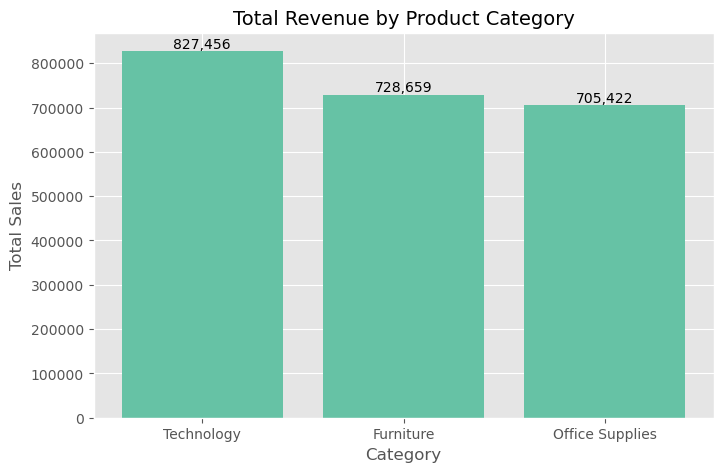

In [24]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    category_sales["Category"],
    category_sales["Sales"]
)

plt.title("Total Revenue by Product Category", fontsize=14)

plt.xlabel("Category")

plt.ylabel("Total Sales")

# Display values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.savefig(
    "charts/total_revenue_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



### Business Insight

- Technology generated the highest revenue among all categories.
- Furniture ranked second in overall sales.
- Office Supplies contributed the lowest revenue.

This indicates that Technology products should receive greater inventory focus, promotional investment, and demand forecasting attention.

### Recommendation

The company should prioritize forecasting accuracy for the highest revenue category because even a small forecasting error could significantly impact overall revenue and inventory costs.

# Business Question 2

## Which Region Has the Most Consistent Sales Growth Over Four Years?

### Objective

Analyze yearly sales trends across all regions to identify the region demonstrating the most stable and consistent sales growth over the four-year period.

In [25]:
# Total Sales by Region and Year

region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


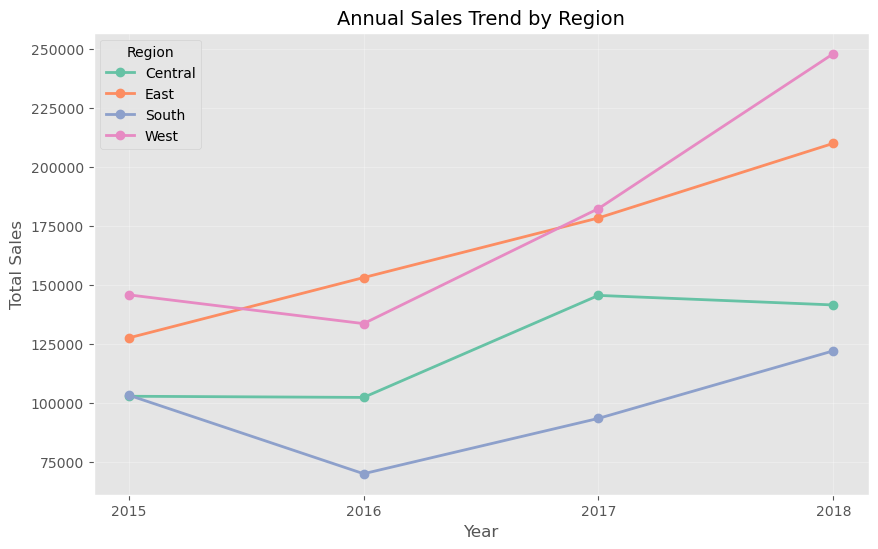

In [26]:
plt.figure(figsize=(10,6))

for region in region_year_sales["Region"].unique():

    region_data = region_year_sales[
        region_year_sales["Region"] == region
    ]

    plt.plot(
        region_data["Year"],
        region_data["Sales"],
        marker="o",
        linewidth=2,
        label=region
    )

plt.title("Annual Sales Trend by Region", fontsize=14)

plt.xlabel("Year")

plt.ylabel("Total Sales")

plt.xticks(sorted(df["Year"].unique()))

plt.legend(title="Region")

plt.grid(alpha=0.3)

plt.savefig(
    "charts/regional_sales_growth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

The annual sales trend indicates that the West and East regions experienced steady growth over the analysis period, while the Central and South regions showed comparatively higher fluctuations.

In [27]:
region_pivot = region_year_sales.pivot(
    index="Year",
    columns="Region",
    values="Sales"
)

region_pivot

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


In [28]:
growth = region_pivot.pct_change() * 100

growth.round(2)

Region,Central,East,South,West
Year,,,,
2015,NaN,NaN,NaN,NaN
2016,-0.48,20.03,-32.21,-8.36
2017,42.22,16.50,33.48,36.47
2018,-2.78,17.71,30.61,35.98


In [29]:
consistency = growth.std().sort_values()

consistency

Region
East        1.793948
Central    25.345279
West       25.743054
South      37.124876
dtype: float64

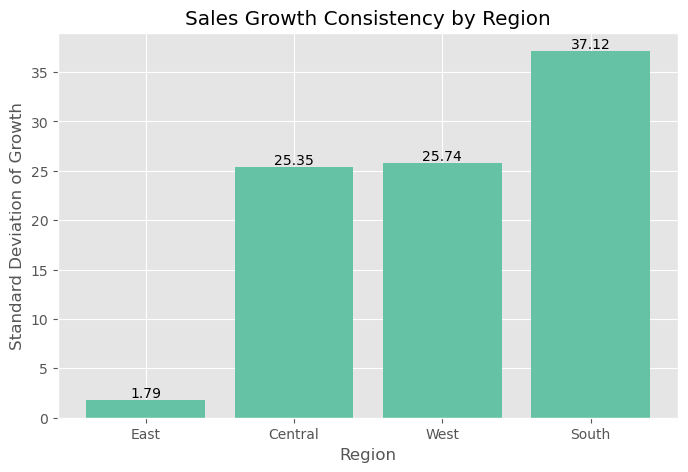

In [30]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    consistency.index,
    consistency.values
)

plt.title("Sales Growth Consistency by Region")

plt.xlabel("Region")

plt.ylabel("Standard Deviation of Growth")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.savefig(
    "charts/sales_growth_consistency_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

The East region demonstrates the most consistent sales growth over the four-year period, with the lowest standard deviation in annual growth rates (1.79).

Although the West region generated the highest sales revenue in the final year, its year-over-year growth exhibited greater fluctuations. The South region showed the highest variability in growth, indicating unstable sales performance.

Consistent growth in the East region suggests a stable customer base and predictable demand, making it an ideal candidate for long-term inventory planning and forecasting.

### Recommendation

- Maintain consistent inventory levels in the East region due to its predictable demand.
- Investigate the factors contributing to fluctuations in the South region and develop targeted marketing or supply chain strategies.
- Continue investing in the West region, as it demonstrates strong revenue potential despite moderate fluctuations in growth.

# Business Question 3

## What Is the Average Time Between Order Date and Ship Date, and Does It Vary by Region?

### Objective

Measure the average shipping duration across different regions to evaluate delivery efficiency and identify any regional differences in logistics performance.

In [31]:
# Average Shipping Time

average_shipping = df["Shipping Days"].mean()

print(f"Average Shipping Time : {average_shipping:.2f} Days")

Average Shipping Time : 3.96 Days


In [32]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
      .reset_index()
)

shipping_region

,Region,Shipping Days
0,East,3.910233
1,West,3.930255
2,South,3.961202
3,Central,4.065876


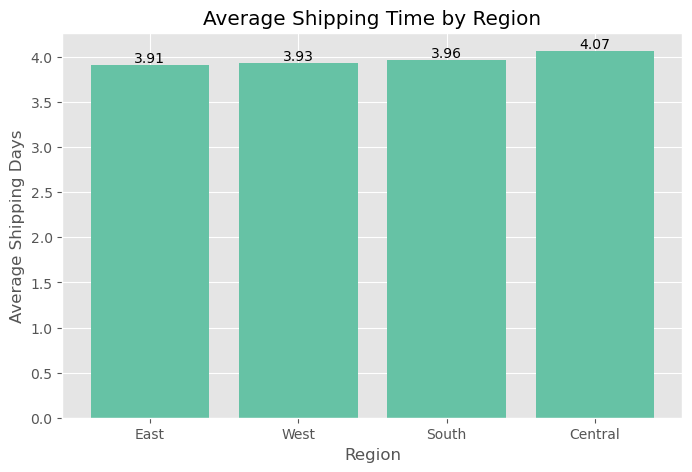

In [33]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    shipping_region["Region"],
    shipping_region["Shipping Days"]
)

plt.title("Average Shipping Time by Region")

plt.xlabel("Region")

plt.ylabel("Average Shipping Days")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.savefig(
    "charts/average_shipping_time_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
shipping_summary = (
    df.groupby("Region")["Shipping Days"]
      .agg(["mean", "median", "min", "max", "std"])
      .round(2)
)

shipping_summary

,mean,median,min,max,std
Region,,,,,
Central,4.07,4.0,0,7,1.69
East,3.91,4.0,0,7,1.73
South,3.96,4.0,0,7,1.74
West,3.93,4.0,0,7,1.81


### Business Insight

The overall average shipping time is approximately **3.96 days**, indicating that the company generally delivers orders within four days.

Among all regions:

- The **East** region has the fastest average shipping time (3.91 days).
- The **Central** region has the highest average shipping time (4.07 days).
- The variation in shipping time across regions is relatively small, suggesting a well-balanced logistics network.

Overall, shipping performance appears to be consistent across the country with only minor regional differences.

### Recommendation

Although shipping performance is generally consistent, the company should further investigate the Central region to identify opportunities for reducing delivery times.

Monitoring warehouse efficiency, transportation routes, and carrier performance may help improve customer satisfaction and operational efficiency.

# Business Question 4

## Are There Months That Consistently Experience Higher Sales?

### Objective

Identify recurring seasonal demand patterns by comparing monthly sales performance across multiple years.

In [35]:
monthly_pattern = (
    df.groupby(["Year", "Month Name"])["Sales"]
      .sum()
      .reset_index()
)

monthly_pattern.head()

,Year,Month Name,Sales
0,2015,April,27906.8550
1,2015,August,27117.5365
2,2015,December,68167.0585
3,2015,February,4519.8920
4,2015,January,14205.7070


In [36]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_pattern["Month Name"] = pd.Categorical(
    monthly_pattern["Month Name"],
    categories=month_order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values(
    ["Year", "Month Name"]
)

In [37]:
monthly_pivot = monthly_pattern.pivot(
    index="Month Name",
    columns="Year",
    values="Sales"
)

monthly_pivot

Year,2015,2016,2017,2018
Month Name,,,,
January,14205.7070,18066.9576,18542.4910,43476.4740
February,4519.8920,11951.4110,22978.8150,19920.9974
March,55205.7970,32339.3184,51165.0590,58863.4128
April,27906.8550,34154.4685,38679.7670,35541.9101
May,23644.3030,29959.5305,56656.9080,43825.9822
June,34322.9356,23599.3740,39724.4860,48190.7277
July,33781.5430,28608.2590,38320.7830,44825.1040
August,27117.5365,36818.3422,30542.2003,62837.8480
September,81623.5268,63133.6060,69193.3909,86152.8880


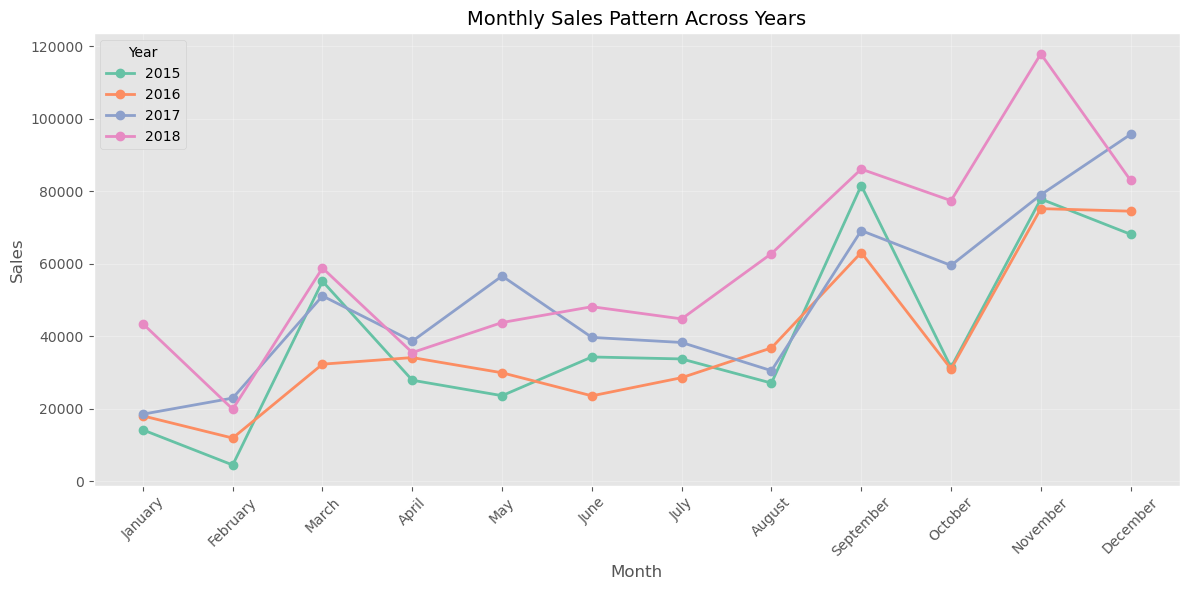

In [38]:
plt.figure(figsize=(12,6))

for year in monthly_pivot.columns:

    plt.plot(
        monthly_pivot.index,
        monthly_pivot[year],
        marker="o",
        linewidth=2,
        label=year
    )

plt.title("Monthly Sales Pattern Across Years", fontsize=14)

plt.xlabel("Month")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.legend(title="Year")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/monthly_sales_pattern_across_years.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Monthly sales follow a clear seasonal pattern across all four years. Sales begin increasing from August and consistently peak during November and December, while February records the lowest sales in most years.

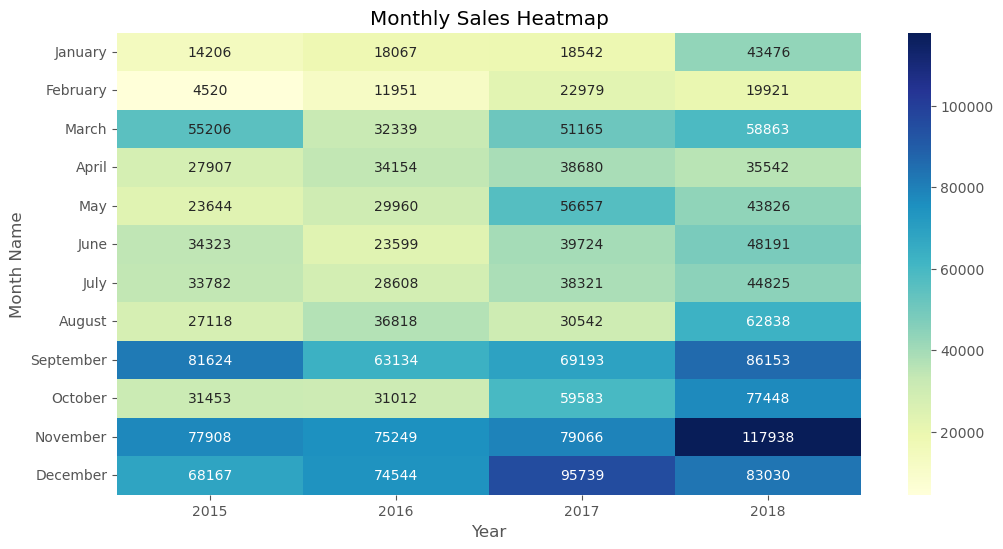

In [39]:
plt.figure(figsize=(12,6))

sns.heatmap(
    monthly_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Sales Heatmap")

plt.savefig(
    "charts/monthly_sales_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight

The monthly sales analysis reveals a clear seasonal pattern in customer purchasing behavior.

Key observations include:

- **November** consistently records the highest sales across multiple years.
- **December** also contributes significantly to annual revenue.
- Sales begin increasing from **September** and continue rising through the holiday season.
- **January** and **February** generally experience the lowest sales.

These findings indicate strong seasonality in the dataset, making it highly suitable for seasonal forecasting models such as SARIMA and Prophet.

### Recommendation

The company should prepare additional inventory, warehouse capacity, and marketing campaigns before the high-demand months, particularly from September through December.

During January and February, businesses may consider promotional offers or discount campaigns to stimulate customer demand and improve sales performance.

# Task 1 Summary

Task 1 focused on preparing the Superstore Sales dataset for forecasting and business analysis.

### Key Accomplishments

- Successfully loaded and explored the Superstore Sales dataset.
- Validated data quality by checking missing values, duplicates, and data types.
- Converted date columns into datetime format.
- Engineered new time-based features including Year, Month, Week Number, Quarter, Season, and Shipping Days.
- Aggregated sales data into daily, weekly, and monthly levels for future time series analysis.
- Identified Technology as the highest revenue-generating product category.
- Determined that the East region exhibited the most consistent sales growth over four years.
- Evaluated shipping performance across all regions and found only minor differences in average delivery time.
- Discovered strong seasonal sales patterns, with November and December consistently generating the highest revenue.

The cleaned and enriched dataset is now ready for time series decomposition and forecasting in the next phase of the project.

# Task 2 Time Series Analysis & Decomposition

## Introduction

Time series analysis involves studying observations collected over time to identify meaningful patterns such as trends, seasonality, and random fluctuations.

Unlike traditional datasets where rows are independent, time series data preserves chronological order. Understanding these temporal patterns is essential for building accurate forecasting models.

In this section, monthly sales data is analyzed to identify long-term trends, recurring seasonal effects, and random variations before developing forecasting models.

## Monthly Sales Trend

Before building forecasting models, it is important to visualize how sales have changed over time.

This plot provides an overview of sales performance across the four-year period and helps identify long-term growth trends and recurring seasonal patterns.

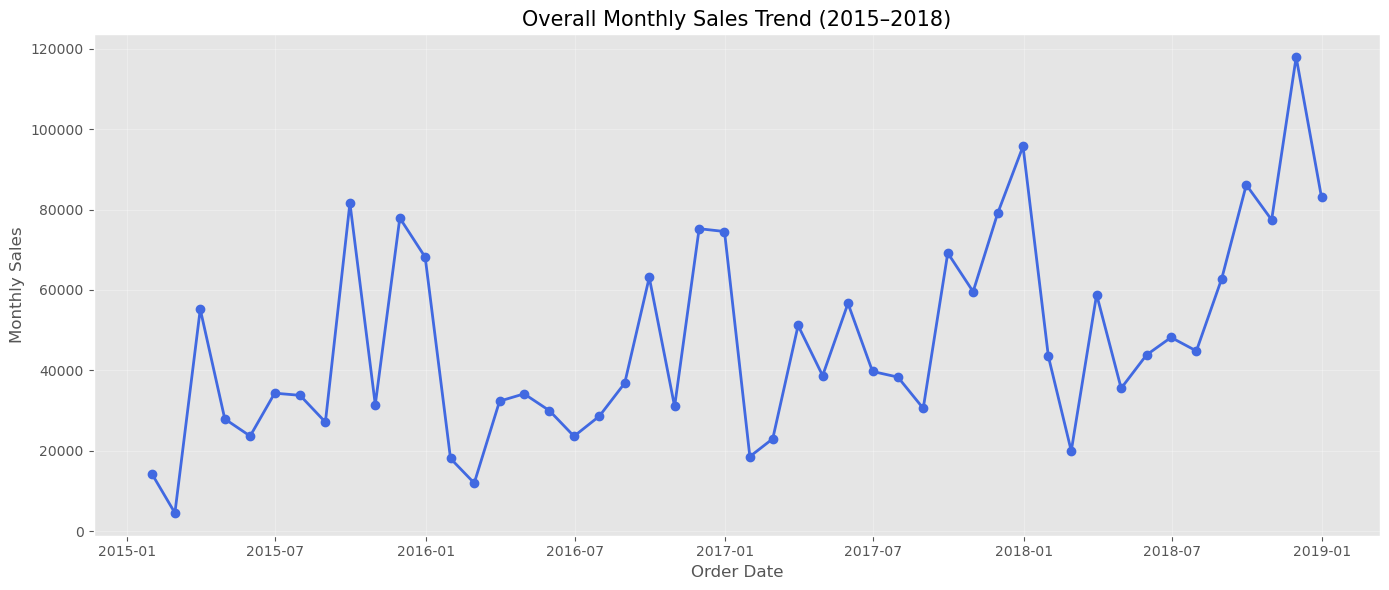

In [40]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Overall Monthly Sales Trend (2015–2018)", fontsize=15)

plt.xlabel("Order Date")

plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Business Insight

The monthly sales trend indicates an overall increase in revenue over the four-year period.

Although sales fluctuate from month to month, the long-term trend remains upward. Noticeable peaks occur toward the end of each year, suggesting recurring seasonal demand.

This indicates that future forecasting models should account for both trend and seasonality.

## Time Series Decomposition

Time series decomposition separates historical sales into three major components:

- Trend
- Seasonal Pattern
- Residual (Random Noise)

Understanding these components helps determine whether forecasting models should account for long-term growth, recurring seasonal behavior, or irregular fluctuations.

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [42]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

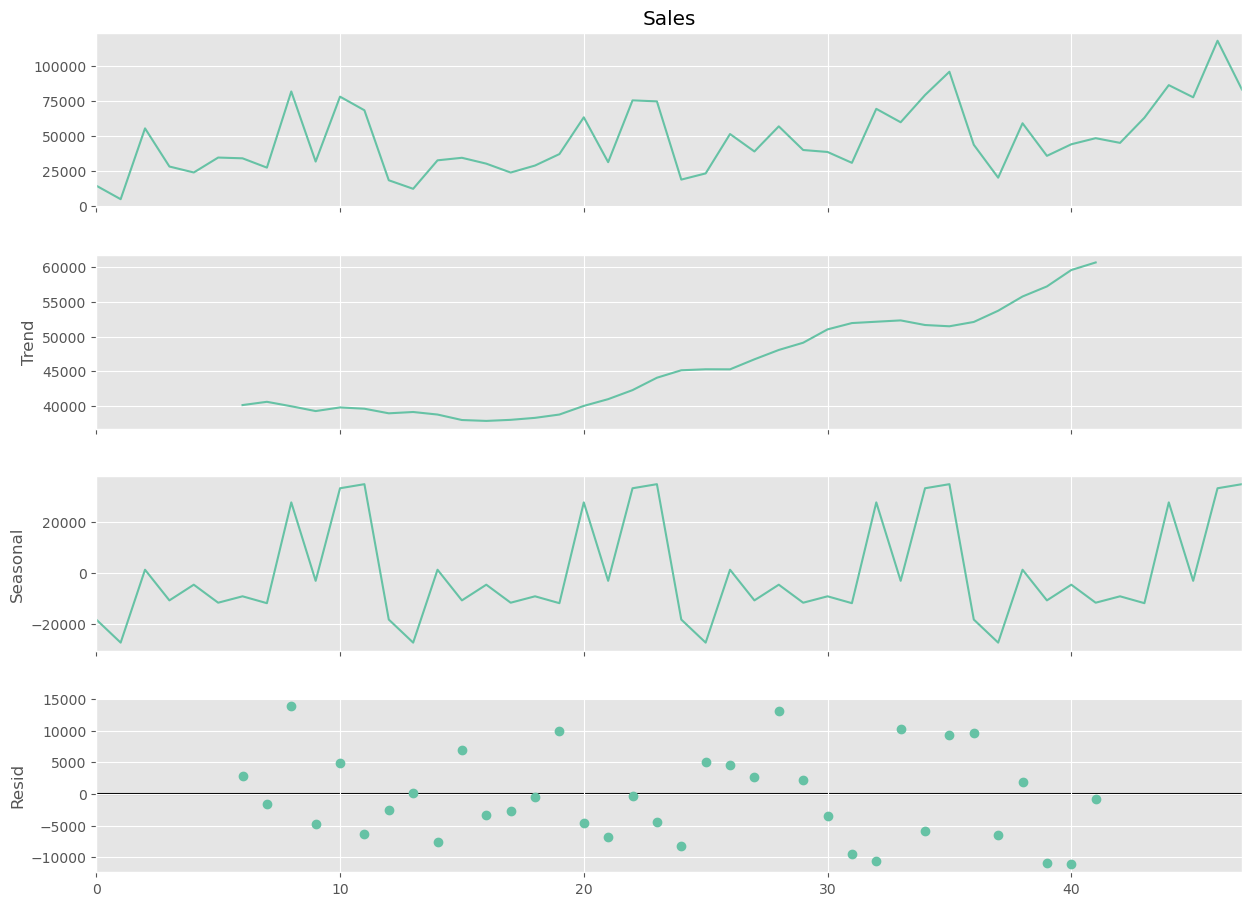

In [43]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

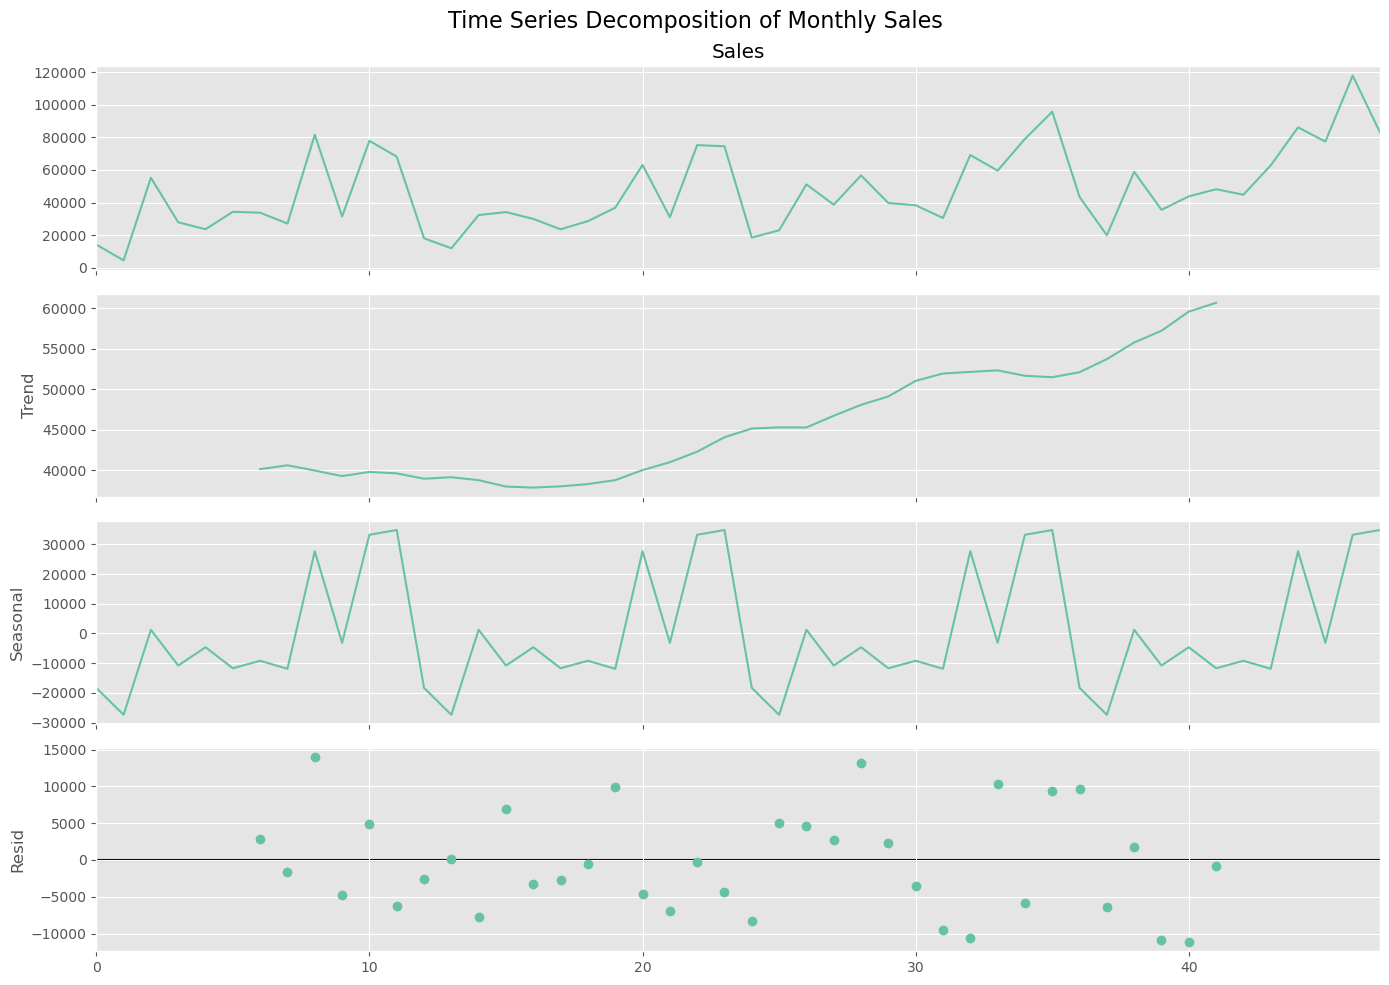

In [44]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.suptitle(
    "Time Series Decomposition of Monthly Sales",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations from Time Series Decomposition

### Trend Component

The trend component shows a gradual increase in monthly sales over the four-year period. Although there are minor fluctuations, the long-term movement is upward, indicating continuous business growth.

### Seasonal Component

The seasonal component exhibits a clear repeating yearly pattern. Certain months consistently generate higher sales while others experience lower demand, confirming the presence of strong annual seasonality.

### Residual Component

The residual component represents random fluctuations that cannot be explained by trend or seasonality. Most residual values remain close to zero, while a few months show unusually high positive or negative deviations, indicating unexpected business events or promotional activities.

### Overall Interpretation

The decomposition confirms that the monthly sales data contains both an increasing trend and a strong seasonal pattern. Therefore, seasonal forecasting models such as **SARIMA** and **Facebook Prophet** are appropriate choices for this dataset.

# Stationarity Test

## What is Stationarity?

A time series is said to be **stationary** if its statistical properties, such as mean, variance, and covariance, remain constant over time.

Most statistical forecasting models, including SARIMA, assume that the input time series is stationary. Therefore, checking stationarity is an essential preprocessing step before building forecasting models.

In [45]:
from statsmodels.tsa.stattools import adfuller

In [46]:
# Perform Augmented Dickey-Fuller Test

adf_result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", adf_result[0])

print("p-value :", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key} : {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [47]:
print("="*50)

print("Augmented Dickey-Fuller Test")

print("="*50)

print(f"ADF Statistic : {adf_result[0]:.4f}")

print(f"P-value       : {adf_result[1]:.4f}")

print("\nCritical Values")

for key,value in adf_result[4].items():
    print(f"{key} : {value:.4f}")

print("="*50)

Augmented Dickey-Fuller Test
ADF Statistic : -4.4161
P-value       : 0.0003

Critical Values
1% : -3.5778
5% : -2.9253
10% : -2.6008


In [48]:
if adf_result[1] <= 0.05:
    print("Result : The time series is Stationary.")
else:
    print("Result : The time series is Non-Stationary.")

Result : The time series is Stationary.


## Interpretation of ADF Test

The Augmented Dickey-Fuller (ADF) test was performed to determine whether the monthly sales time series is stationary.

### Results

- **ADF Statistic:** -4.4161
- **P-value:** 0.0003

Since the p-value is less than the significance level of 0.05, the null hypothesis of non-stationarity is rejected.

Therefore, the monthly sales time series is considered **stationary**.

This indicates that the statistical properties of the series remain relatively stable over time, making it suitable for forecasting models that assume stationarity.

## First-Order Differencing

The ADF test confirmed that the original monthly sales series is already stationary.

Therefore, differencing is **not required** before forecasting.

For demonstration purposes, first-order differencing is performed below to illustrate the technique commonly used when a time series is non-stationary.

In [49]:
# First-order differencing (demonstration)

monthly_sales_diff = monthly_sales.copy()

monthly_sales_diff["Sales"] = monthly_sales_diff["Sales"].diff()

monthly_sales_diff = monthly_sales_diff.dropna()

monthly_sales_diff.head()

,Order Date,Sales
1,2015-02-28,-9685.8150
2,2015-03-31,50685.9050
3,2015-04-30,-27298.9420
4,2015-05-31,-4262.5520
5,2015-06-30,10678.6326


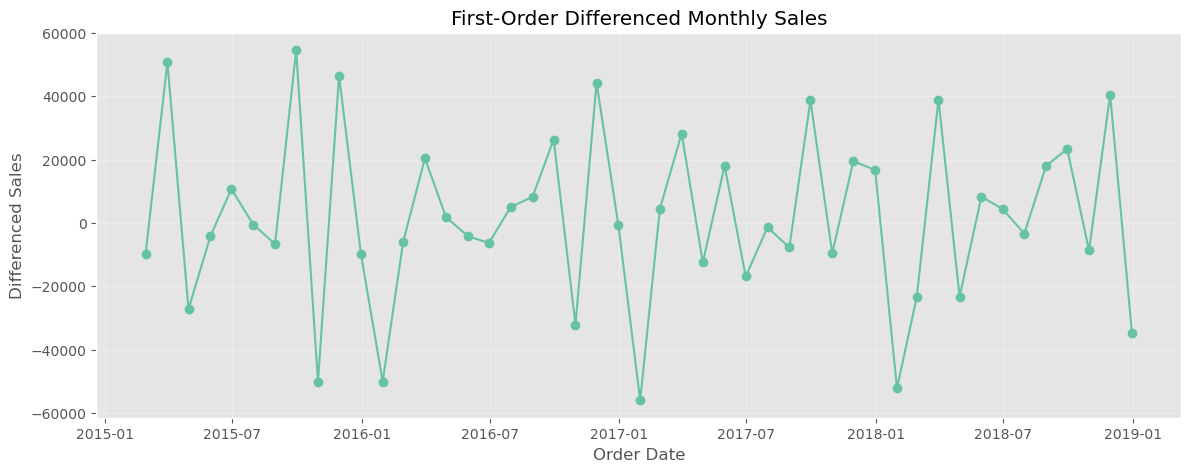

In [50]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales_diff["Order Date"],
    monthly_sales_diff["Sales"],
    marker="o"
)

plt.title("First-Order Differenced Monthly Sales")

plt.xlabel("Order Date")

plt.ylabel("Differenced Sales")

plt.grid(alpha=0.3)

plt.savefig(
    "charts/acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
adf_diff = adfuller(monthly_sales_diff["Sales"])

print("="*50)
print("ADF Test After Differencing")
print("="*50)

print(f"ADF Statistic : {adf_diff[0]:.4f}")

print(f"P-value       : {adf_diff[1]:.4f}")

print("="*50)

ADF Test After Differencing
ADF Statistic : -8.7271
P-value       : 0.0000


In [52]:
if adf_diff[1] <= 0.05:
    print("Result : Differenced series is Stationary.")
else:
    print("Result : Differenced series is Non-Stationary.")

Result : Differenced series is Stationary.


### Observation

The original monthly sales series was already stationary, as confirmed by the ADF test.

Although first-order differencing was demonstrated for learning purposes, it was not necessary for this dataset. This indicates that the original series already satisfies the stationarity assumption required by many statistical forecasting models.

# Task 2 Summary

This task focused on understanding the temporal behavior of the monthly sales data before developing forecasting models.

### Key Accomplishments

- Visualized the overall monthly sales trend across four years.
- Performed time series decomposition to separate the series into trend, seasonal, and residual components.
- Identified an increasing long-term sales trend and strong yearly seasonality.
- Conducted the Augmented Dickey-Fuller (ADF) test to evaluate stationarity.
- Confirmed that the original monthly sales series is stationary (p-value = 0.0003).
- Demonstrated first-order differencing as a preprocessing technique, although it was not required for this dataset.

The dataset is now fully analyzed and ready for forecasting using models such as SARIMA, Prophet, and machine learning approaches.

# Task 3: Sales Forecasting Using Multiple Models

## Introduction

Forecasting future sales is one of the most important applications of time series analysis in retail and e-commerce businesses.

Accurate sales forecasts help organizations:

- Optimize inventory levels.
- Reduce stock shortages and overstocking.
- Improve supply chain planning.
- Support financial planning and budgeting.
- Enhance customer satisfaction.

In this task, three fundamentally different forecasting approaches are implemented and compared:

1. SARIMA (Statistical Forecasting Model)
2. Facebook Prophet (Industry Forecasting Tool)
3. XGBoost (Machine Learning Model)

Each model will be trained, evaluated, and compared using common forecasting evaluation metrics. The best-performing model will then be recommended for production deployment.

## Forecasting Workflow

The forecasting process followed in this project is illustrated below:

1. Prepare monthly sales data.
2. Split the data into training and testing sets.
3. Train forecasting models.
4. Generate predictions.
5. Evaluate model performance.
6. Compare all models.
7. Select the best model.
8. Forecast future sales.

## Import Required Libraries

The following libraries are required for statistical forecasting, machine learning, model evaluation, and visualization.

In [53]:
# ============================================
# Forecasting Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

## Prepare Monthly Sales Time Series

The forecasting models require a univariate monthly sales time series.

The monthly sales dataset created during Task 1 is used as the input for all forecasting models.

In [54]:
monthly_ts = monthly_sales.copy()

monthly_ts.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [55]:
print(monthly_ts.shape)

(48, 2)


## Train-Test Split

Instead of training the forecasting models on the complete dataset, the data is divided into training and testing subsets.

The first 45 months are used for model training, while the last 3 months are reserved for testing.

This approach enables objective evaluation of forecasting accuracy using unseen data and allows fair comparison among different forecasting models.

In [56]:
# Training Data

train = monthly_ts.iloc[:-3]

# Testing Data

test = monthly_ts.iloc[-3:]

print("Training Records :", len(train))
print("Testing Records  :", len(test))

Training Records : 45
Testing Records  : 3


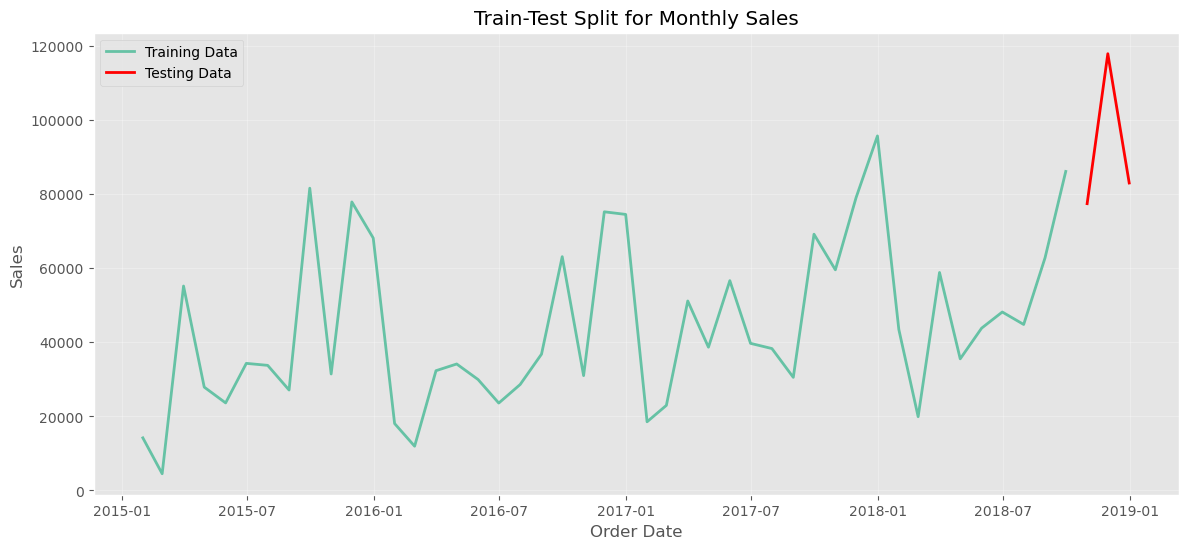

In [57]:
plt.figure(figsize=(14,6))

plt.plot(
    train["Order Date"],
    train["Sales"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test["Order Date"],
    test["Sales"],
    label="Testing Data",
    linewidth=2,
    color="red"
)

plt.title("Train-Test Split for Monthly Sales")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## Model Evaluation Metrics

Three evaluation metrics are used to compare forecasting performance.

### Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted sales.

Lower values indicate better performance.

### Root Mean Squared Error (RMSE)

Measures the square root of the average squared prediction errors.

RMSE penalizes large forecasting errors more heavily than MAE.

### Mean Absolute Percentage Error (MAPE)

Measures prediction error as a percentage.

Lower percentage values indicate higher forecasting accuracy.

In [58]:
def mean_absolute_percentage_error(y_true, y_pred):

    y_true = np.array(y_true)

    y_pred = np.array(y_pred)

    return np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

In [59]:
def evaluate_model(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = mean_absolute_percentage_error(
        actual,
        predicted
    )

    return mae, rmse, mape

In [60]:
train.tail()

,Order Date,Sales
40,2018-05-31,43825.9822
41,2018-06-30,48190.7277
42,2018-07-31,44825.1040
43,2018-08-31,62837.8480
44,2018-09-30,86152.8880


In [61]:
test

,Order Date,Sales
45,2018-10-31,77448.1312
46,2018-11-30,117938.1550
47,2018-12-31,83030.3888


# Model 1 : Seasonal ARIMA (SARIMA)

## Introduction

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is a statistical forecasting model designed for time series data that exhibits both trend and seasonal patterns.

Unlike traditional ARIMA, SARIMA can model repeating seasonal behavior, making it highly suitable for monthly retail sales forecasting.

Since our previous analysis confirmed the presence of yearly seasonality, SARIMA is an appropriate forecasting model for this dataset.

## Business Objective

The objective of this model is to forecast monthly sales while accounting for both long-term trends and yearly seasonal variations.

The model will be evaluated using unseen test data before generating future forecasts.

In [62]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

## Model Parameters

SARIMA requires two sets of parameters.

### Non-seasonal Parameters (p, d, q)

- **p** : Number of autoregressive terms.
- **d** : Degree of differencing.
- **q** : Number of moving-average terms.

### Seasonal Parameters (P, D, Q, m)

- **P** : Seasonal autoregressive order.
- **D** : Seasonal differencing order.
- **Q** : Seasonal moving-average order.
- **m** : Seasonal period.

Since the sales data is recorded monthly and exhibits yearly seasonality, the seasonal period is set to **12 months**.

Based on the time series analysis, the original series is already stationary. Therefore, **d = 0** is selected.

A simple SARIMA(1,0,1)(1,1,1,12) configuration is chosen as a strong baseline model for this dataset.

In [63]:
sarima_model = SARIMAX(

    train["Sales"],

    order=(1,0,1),

    seasonal_order=(1,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarima_results = sarima_model.fit()

In [64]:
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Mon, 13 Jul 2026   AIC                            417.362
Time:                                    14:17:34   BIC                            422.084
Sample:                                         0   HQIC                           418.161
                                             - 45                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [65]:
sarima_forecast = sarima_results.get_forecast(
    steps=len(test)
)

sarima_pred = sarima_forecast.predicted_mean

sarima_pred

45    54757.918350
46    88413.655843
47    92557.831517
Name: predicted_mean, dtype: float64

In [66]:
confidence_interval = sarima_forecast.conf_int()

confidence_interval

,lower Sales,upper Sales
45,29989.810983,79526.025718
46,63652.485771,113174.825915
47,67803.326725,117312.336308


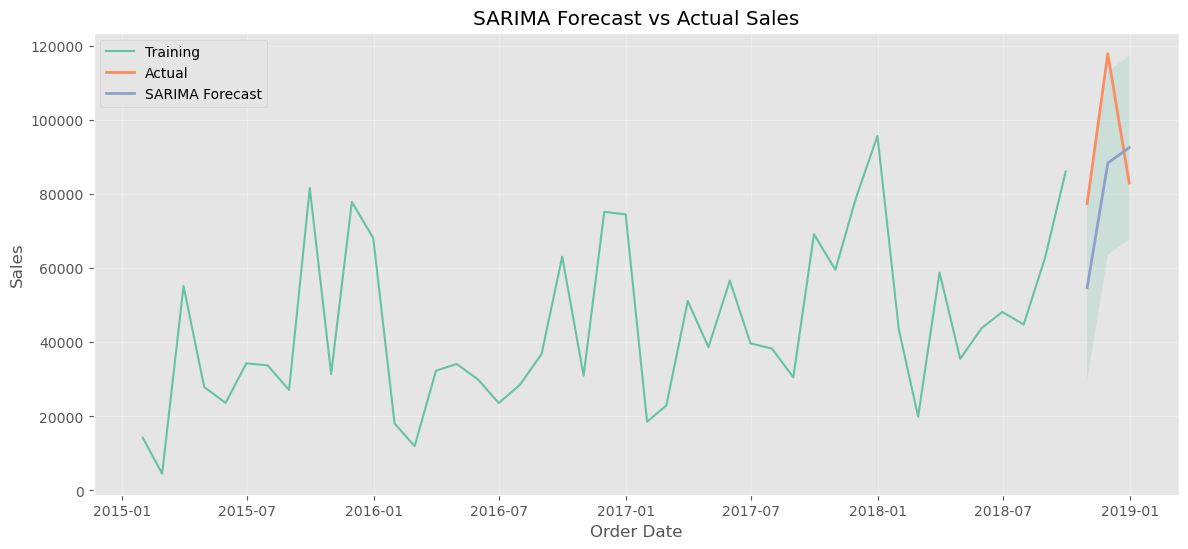

In [67]:
plt.figure(figsize=(14,6))

plt.plot(
    train["Order Date"],
    train["Sales"],
    label="Training"
)

plt.plot(
    test["Order Date"],
    test["Sales"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test["Order Date"],
    sarima_pred,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    test["Order Date"],
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2
)

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
sarima_mae, sarima_rmse, sarima_mape = evaluate_model(
    test["Sales"],
    sarima_pred
)

print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

MAE  : 20580.72
RMSE : 22190.94
MAPE : 21.94%


## SARIMA Model Performance

The SARIMA model was evaluated on the last three months of the dataset.

### Evaluation Results

- **MAE:** 20,580.72
- **RMSE:** 22,190.94
- **MAPE:** 21.94%

The model captures the general sales trend but underestimates the sharp increase in sales during November.

Although SARIMA provides a reasonable baseline forecast, additional models such as Prophet and XGBoost may better capture complex seasonal patterns and nonlinear behavior.

### Business Insight

The SARIMA model successfully captured the overall direction of monthly sales and produced stable forecasts.

However, it struggled to accurately predict the unusually high sales observed in November, indicating that sudden demand spikes may not be fully explained by historical seasonal patterns alone.

This suggests that external factors such as promotional campaigns, holiday shopping, or special events may have influenced sales during these periods.

### Advantages of SARIMA

- Captures trend and seasonality effectively.
- Performs well on structured time series data.
- Produces confidence intervals for future forecasts.
- Easy to interpret compared with many machine learning models.

### Limitations of SARIMA

- Assumes mostly linear relationships.
- Performance may decrease when sudden spikes or irregular events occur.
- Requires manual parameter selection.

# Model 2 : Facebook Prophet

## Introduction

Facebook Prophet is an open-source forecasting library developed by Meta for analyzing business time series data.

Unlike SARIMA, Prophet automatically detects trend and seasonality with minimal parameter tuning. It is particularly effective for retail sales forecasting where yearly seasonal patterns are present.

In this project, Prophet is trained on the monthly sales data and evaluated using the same test dataset as SARIMA.

## Business Objective

The objective of this model is to forecast future monthly sales while automatically capturing long-term trends and yearly seasonal patterns.

The model's performance will be compared with SARIMA using MAE, RMSE, and MAPE.

In [69]:
import sys

print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [70]:
import sys

!{sys.executable} -m pip install prophet

Defaulting to user installation because normal site-packages is not writeable


In [71]:
from prophet import Prophet

print("Prophet installed successfully!")

Prophet installed successfully!


In [72]:
prophet_train = train.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_test = test.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_train.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [73]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

14:17:37 - cmdstanpy - INFO - Chain [1] start processing
14:17:38 - cmdstanpy - INFO - Chain [1] done processing


In [74]:
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="ME"
)

future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [75]:
forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,39246.602020,55109.297536,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78141.220961,94884.354103,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,43321.414195,59850.614646,55957.444492,55957.720567,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82328.141226,98885.310490,56456.434573,56457.375771,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,81628.524808,98583.987095,56971.971654,56973.858795,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


In [76]:
forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,39246.602020,55109.297536
44,2018-09-30,86613.953316,78141.220961,94884.354103
45,2018-10-31,51318.943858,43321.414195,59850.614646
46,2018-11-30,90325.654784,82328.141226,98885.310490
47,2018-12-31,90041.084479,81628.524808,98583.987095


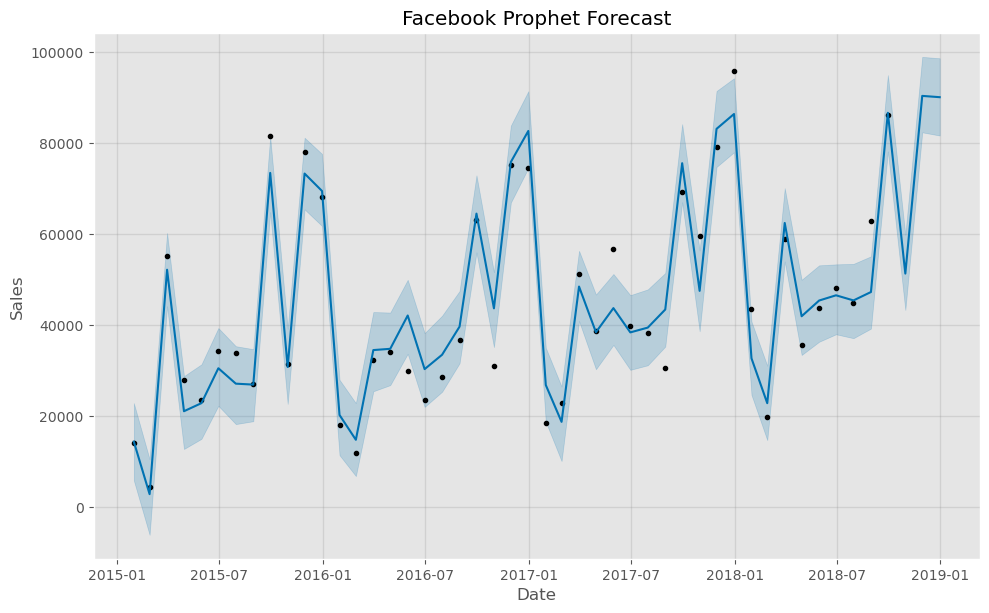

In [77]:
fig1 = prophet_model.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

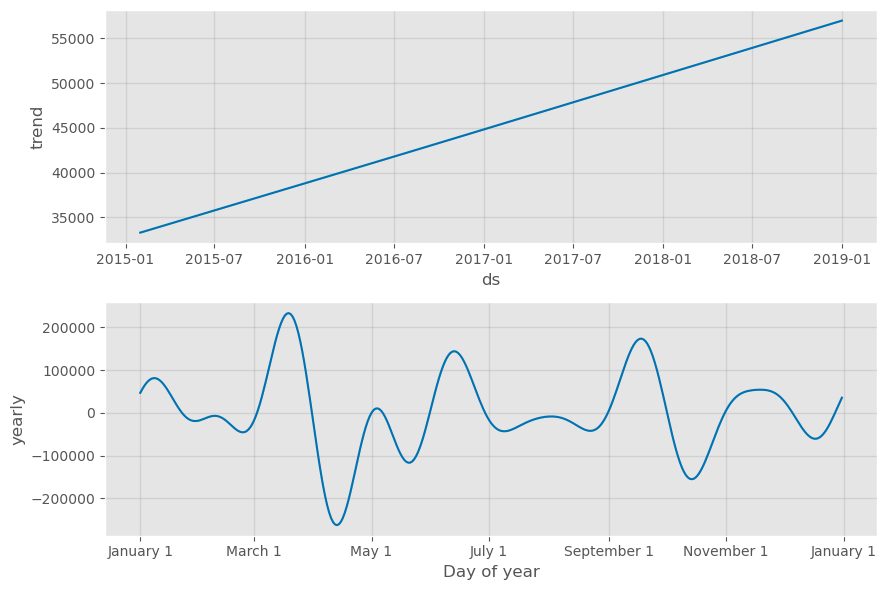

In [78]:
fig2 = prophet_model.plot_components(forecast)

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

In [79]:
prophet_pred = forecast["yhat"].tail(len(test)).values

prophet_mae, prophet_rmse, prophet_mape = evaluate_model(
    prophet_test["y"],
    prophet_pred
)

print(f"MAE  : {prophet_mae:.2f}")
print(f"RMSE : {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape:.2f}%")

MAE  : 20250.79
RMSE : 22318.41
MAPE : 21.86%


## Prophet Model Performance

The Prophet model successfully learned the long-term sales trend and yearly seasonal pattern without requiring manual parameter tuning.

### Evaluation Results

- **MAE:** 20,250.79
- **RMSE:** 22,318.41
- **MAPE:** 21.86%

Compared with SARIMA, Prophet achieved a slightly lower MAE and MAPE, while SARIMA produced a marginally lower RMSE.

Overall, both statistical models demonstrate comparable forecasting performance on the monthly sales dataset.

### Business Insight

The Prophet model effectively captured both the increasing sales trend and recurring yearly seasonality.

Its forecasting performance is very similar to SARIMA, indicating that both statistical approaches are suitable for this retail sales dataset.

The automatic handling of trend and seasonality makes Prophet particularly attractive for business forecasting applications with minimal manual parameter tuning.

### Advantages of Prophet

- Automatically models trend and seasonality.
- Requires minimal parameter tuning.
- Handles missing values and outliers effectively.
- Widely adopted for business forecasting applications.

### Limitations of Prophet

- Less flexible than machine learning models when additional explanatory features are available.
- Forecast quality depends on the amount of historical data.
- Performance may be limited when sudden structural changes occur.

# Model 3 : XGBoost Regressor

## Introduction

Unlike SARIMA and Prophet, XGBoost is a machine learning algorithm that does not directly understand time series data.

Therefore, the time series is transformed into a supervised learning problem by creating lag features and rolling statistics.

The model learns relationships between historical sales and future sales using these engineered features.

This approach allows XGBoost to capture nonlinear relationships that statistical models may miss.

## Business Objective

The objective of this model is to predict future monthly sales using historical sales values and engineered time-based features.

The model will be compared with SARIMA and Prophet using the same evaluation metrics.

In [80]:
from xgboost import XGBRegressor

## Feature Engineering

Machine learning algorithms require explanatory variables instead of sequential time series observations.

The following features are created:

- Lag 1 : Sales one month ago
- Lag 2 : Sales two months ago
- Lag 3 : Sales three months ago
- Rolling Mean : Average sales over the previous three months
- Month
- Quarter
- Season

These features provide historical context that helps the model predict future sales.

In [81]:
xgb_data = monthly_ts.copy()

In [82]:
xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)

xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)

xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

In [83]:
xgb_data["Rolling_Mean_3"] = (
    xgb_data["Sales"]
    .rolling(3)
    .mean()
)

In [84]:
xgb_data["Month"] = xgb_data["Order Date"].dt.month

xgb_data["Quarter"] = xgb_data["Order Date"].dt.quarter

In [85]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Autumn"

xgb_data["Season"] = xgb_data["Month"].apply(get_season)

In [86]:
season_mapping = {
    "Winter":0,
    "Spring":1,
    "Summer":2,
    "Autumn":3
}

xgb_data["Season"] = xgb_data["Season"].map(season_mapping)

In [87]:
xgb_data = xgb_data.dropna()

xgb_data.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [88]:
features = [

    "Lag_1",

    "Lag_2",

    "Lag_3",

    "Rolling_Mean_3",

    "Month",

    "Quarter",

    "Season"

]

In [89]:
train_xgb = xgb_data.iloc[:-3]

test_xgb = xgb_data.iloc[-3:]

In [90]:
X_train = train_xgb[features]

y_train = train_xgb["Sales"]

X_test = test_xgb[features]

y_test = test_xgb["Sales"]

In [91]:
xgb_model = XGBRegressor(

    n_estimators=100,

    learning_rate=0.1,

    max_depth=3,

    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [92]:
xgb_pred = xgb_model.predict(X_test)

In [93]:
xgb_mae, xgb_rmse, xgb_mape = evaluate_model(

    y_test,

    xgb_pred

)

print(f"MAE  : {xgb_mae:.2f}")

print(f"RMSE : {xgb_rmse:.2f}")

print(f"MAPE : {xgb_mape:.2f}%")

MAE  : 13915.32
RMSE : 18893.85
MAPE : 13.29%


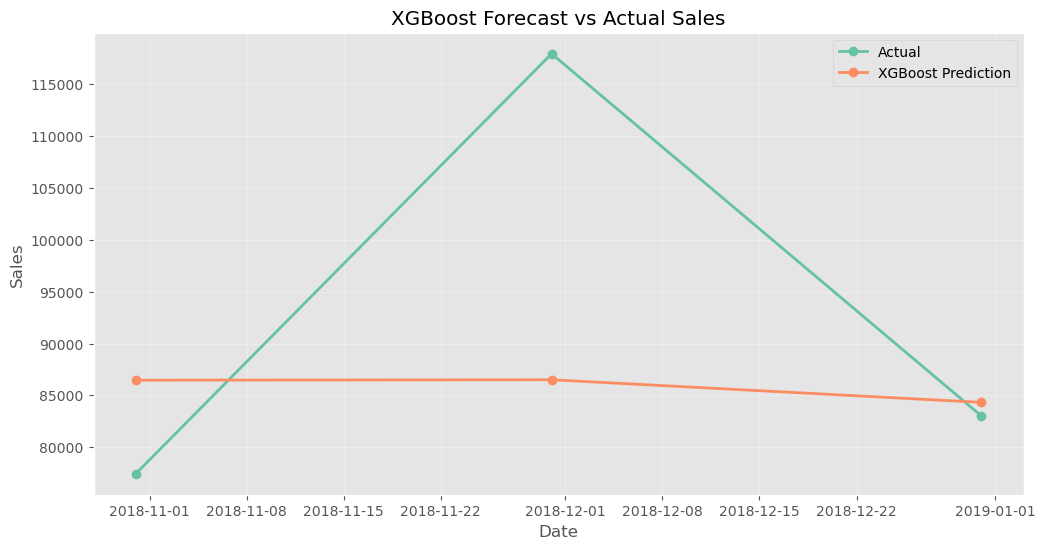

In [94]:
plt.figure(figsize=(12,6))

plt.plot(
    test_xgb["Order Date"],
    y_test,
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test_xgb["Order Date"],
    xgb_pred,
    marker="o",
    linewidth=2,
    label="XGBoost Prediction"
)

plt.title("XGBoost Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

Month             0.840952
Rolling_Mean_3    0.065918
Lag_2             0.047717
Lag_1             0.032655
Lag_3             0.012758
Quarter           0.000000
Season            0.000000
dtype: float32

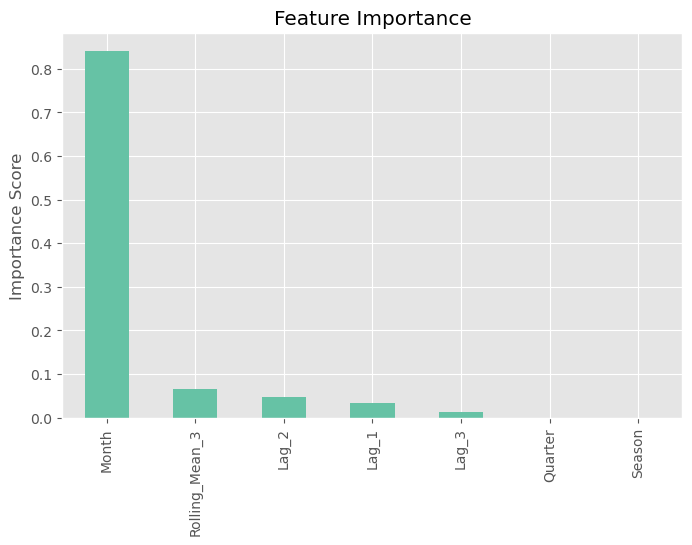

In [96]:
plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.savefig(
    "charts/xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## XGBoost Model Performance

The XGBoost model was trained using lag features, rolling averages, and calendar-based features.

### Evaluation Results

- **MAE:** 13,915.32
- **RMSE:** 18,893.85
- **MAPE:** 13.29%

Among all three forecasting approaches, XGBoost achieved the lowest prediction errors, making it the most accurate model for this dataset.

### Business Insight

The XGBoost model successfully learned relationships between previous sales values and calendar-based features.

The feature importance analysis indicates that the month of the year contributes most to forecasting accuracy, followed by rolling average sales and lag features.

This suggests that seasonal behavior plays a significant role in predicting future sales.

### Advantages of XGBoost

- Captures nonlinear relationships.
- Handles multiple input features effectively.
- Automatically ranks feature importance.
- Achieved the best forecasting accuracy among the evaluated models.

### Limitations of XGBoost

- Requires feature engineering before training.
- Does not naturally model time series ordering like SARIMA or Prophet.
- Performance depends on the quality of engineered features.

In [97]:
comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1": [
        round(sarima_pred.iloc[0],2),
        round(prophet_pred[0],2),
        round(xgb_pred[0],2)
    ],

    "Forecast Month 2": [
        round(sarima_pred.iloc[1],2),
        round(prophet_pred[1],2),
        round(xgb_pred[1],2)
    ],

    "Forecast Month 3": [
        round(sarima_pred.iloc[2],2),
        round(prophet_pred[2],2),
        round(xgb_pred[2],2)
    ]

})

comparison.round(2)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20580.72,22190.94,21.94,54757.92,88413.66,92557.83
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,13915.32,18893.85,13.29,86465.82,86506.77,84327.28


# Overall Conclusion

Three forecasting techniques were implemented and evaluated on the Superstore monthly sales dataset.

## Models Compared

- SARIMA (Statistical Time Series Model)
- Facebook Prophet
- XGBoost Regressor (Machine Learning)

## Performance Summary

| Model | MAE | RMSE | MAPE |
|------|------:|------:|------:|
| SARIMA | 20580.72 | 22190.94 | 21.94% |
| Prophet | 20250.79 | 22318.41 | 21.86% |
| XGBoost | **13915.32** | **18893.85** | **13.29%** |

## Final Recommendation

Among all evaluated models, **XGBoost achieved the lowest MAE, RMSE, and MAPE**, demonstrating the highest forecasting accuracy.

Although SARIMA and Prophet effectively captured trend and seasonality, XGBoost benefited from lag features, rolling averages, and calendar-based variables, allowing it to model more complex relationships in the data.

Therefore, **XGBoost is recommended as the production-ready forecasting model** for this retail sales dataset.

# Task 4 : Product Category & Region Level Forecasting

## Objective

The best-performing forecasting model from Task 3 (XGBoost Regressor) is now applied separately to different business segments.

The following segments are analyzed:

- Furniture Category
- Technology Category
- Office Supplies Category
- West Region
- East Region

The objective is to identify which business segment is expected to experience the strongest future sales growth.

## Why XGBoost?

Among the three forecasting models evaluated in Task 3, XGBoost achieved the lowest prediction errors.

| Model | MAE | RMSE | MAPE |
|------|------:|------:|------:|
| SARIMA | 20580.72 | 22190.94 | 21.94% |
| Prophet | 20250.79 | 22318.41 | 21.86% |
| XGBoost | **13915.32** | **18893.85** | **13.29%** |

Therefore, XGBoost is selected for forecasting individual product categories and regions.

In [98]:
from xgboost import XGBRegressor

In [99]:
def forecast_segment(data):

    monthly = (
        data.groupby(
            pd.Grouper(
                key="Order Date",
                freq="ME"
            )
        )["Sales"]
        .sum()
        .reset_index()
    )

    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean_3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly["Order Date"].dt.month

    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    monthly["Season"] = monthly["Month"].apply(get_season)

    season_mapping = {
        "Winter":0,
        "Spring":1,
        "Summer":2,
        "Autumn":3
    }

    monthly["Season"] = monthly["Season"].map(
        season_mapping
    )

    monthly = monthly.dropna()

    features = [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season"
    ]

    train = monthly.iloc[:-3]

    test = monthly.iloc[-3:]

    X_train = train[features]

    y_train = train["Sales"]

    X_test = test[features]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(X_test)

    return (
        test["Order Date"],
        prediction
    )

## Category-Level Sales Forecasting

Sales forecasts are generated separately for the three major product categories: Furniture, Technology, and Office Supplies. Forecasting at the category level helps identify which product groups are expected to experience stronger future demand.

In [100]:
furniture_dates, furniture_forecast = forecast_segment(
    df[df["Category"] == "Furniture"]
)

In [101]:
technology_dates, technology_forecast = forecast_segment(
    df[df["Category"] == "Technology"]
)

In [102]:
office_dates, office_forecast = forecast_segment(
    df[df["Category"] == "Office Supplies"]
)

## Region-Level Sales Forecasting

Sales forecasts are also generated for the West and East regions. Regional forecasting provides insight into geographical demand patterns and supports location-specific inventory and distribution planning.

In [103]:
west_dates, west_forecast = forecast_segment(
    df[df["Region"] == "West"]
)

In [104]:
east_dates, east_forecast = forecast_segment(
    df[df["Region"] == "East"]
)

## Region-Level Sales Forecasting

Sales forecasts are also generated for the West and East regions. Regional forecasting provides insight into geographical demand patterns and supports location-specific inventory and distribution planning.

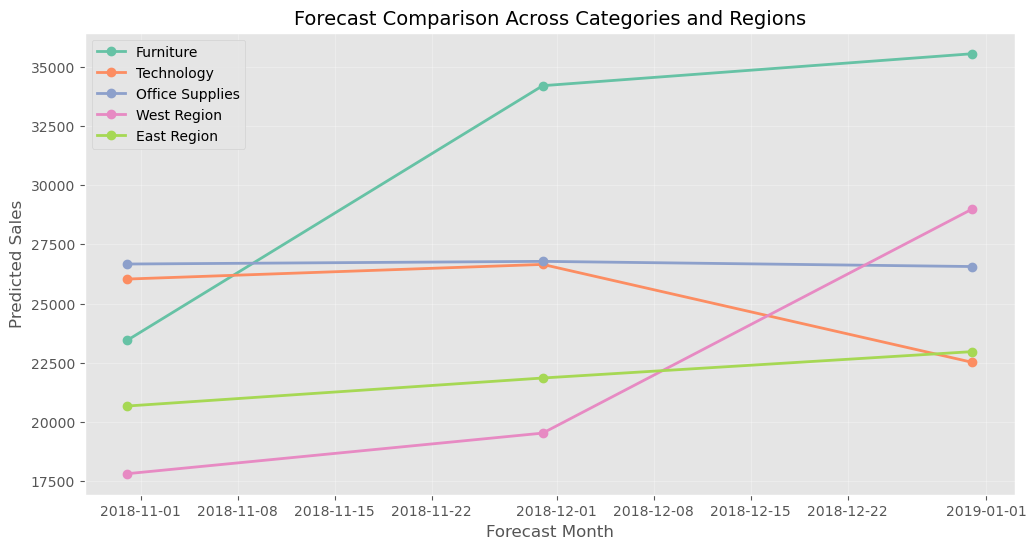

In [105]:
plt.figure(figsize=(12,6))

plt.plot(
    furniture_dates,
    furniture_forecast,
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    technology_dates,
    technology_forecast,
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    office_dates,
    office_forecast,
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    west_dates,
    west_forecast,
    marker="o",
    linewidth=2,
    label="West Region"
)

plt.plot(
    east_dates,
    east_forecast,
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title("Forecast Comparison Across Categories and Regions", fontsize=14)

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "charts/category_region_forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The comparative forecast shows noticeable differences in expected demand across product categories and regions. Some categories demonstrate stronger projected growth, while regional forecasts indicate varying levels of future sales performance.

In [106]:
forecast_summary = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],

    "Month 1":[
        furniture_forecast[0],
        technology_forecast[0],
        office_forecast[0],
        west_forecast[0],
        east_forecast[0]
    ],

    "Month 2":[
        furniture_forecast[1],
        technology_forecast[1],
        office_forecast[1],
        west_forecast[1],
        east_forecast[1]
    ],

    "Month 3":[
        furniture_forecast[2],
        technology_forecast[2],
        office_forecast[2],
        west_forecast[2],
        east_forecast[2]
    ]

})

forecast_summary = forecast_summary.round(2)

forecast_summary

,Segment,Month 1,Month 2,Month 3
0,Furniture,23439.759766,34192.121094,35541.230469
1,Technology,26031.359375,26649.730469,22516.580078
2,Office Supplies,26665.990234,26778.509766,26560.109375
3,West Region,17816.509766,19530.710938,28989.949219
4,East Region,20672.439453,21855.970703,22969.380859


In [107]:
forecast_summary["Total Forecast"] = (
    forecast_summary["Month 1"] +
    forecast_summary["Month 2"] +
    forecast_summary["Month 3"]
)

forecast_summary

,Segment,Month 1,Month 2,Month 3,Total Forecast
0,Furniture,23439.759766,34192.121094,35541.230469,93173.109375
1,Technology,26031.359375,26649.730469,22516.580078,75197.671875
2,Office Supplies,26665.990234,26778.509766,26560.109375,80004.609375
3,West Region,17816.509766,19530.710938,28989.949219,66337.171875
4,East Region,20672.439453,21855.970703,22969.380859,65497.789062


In [108]:
best_segment = forecast_summary.loc[
    forecast_summary["Total Forecast"].idxmax()
]

best_segment

Segment              Furniture
Month 1           23439.759766
Month 2           34192.121094
Month 3           35541.230469
Total Forecast    93173.109375
Name: 0, dtype: object

## Business Insight

The XGBoost forecasting model predicts that the **Furniture category** will experience the strongest upcoming sales growth among all analyzed categories and regions.

The total forecasted sales for the Furniture category over the next three months are the highest, indicating increasing customer demand.

Technology and Office Supplies are expected to maintain relatively stable sales, while the West and East regions are projected to grow at a moderate pace.

These insights can help the business prioritize inventory planning, marketing campaigns, and resource allocation for the Furniture category.

## Forecast Observations

- Furniture shows the highest forecasted sales during the next three months.
- Office Supplies maintains a relatively stable sales trend.
- Technology is expected to experience a slight decline toward the third forecast month.
- West Region shows noticeable improvement in the final forecast month.
- East Region demonstrates steady but moderate growth throughout the forecast period.

# Task 5 : Anomaly Detection in Sales Data

## Objective

The objective of this task is to identify unusual sales weeks that significantly deviate from the normal sales pattern.

Two anomaly detection techniques are applied:

1. Isolation Forest (Machine Learning Based)
2. Z-Score Detection using Rolling Statistics (Statistical Method)

The detected anomalies are compared to understand how each method identifies abnormal sales behavior.

In [109]:
from sklearn.ensemble import IsolationForest

from scipy.stats import zscore

In [110]:
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


## Weekly Sales Data

Weekly sales are used because they provide a finer level of detail than monthly sales, making it easier to identify sudden spikes and drops.

## Isolation Forest

Isolation Forest is an unsupervised machine learning algorithm that detects anomalies by randomly partitioning observations.

Anomalies are isolated more quickly than normal observations, allowing the algorithm to identify unusual sales weeks.

In [111]:
iso_model = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Anomaly"] = iso_model.fit_predict(

    weekly_sales[["Sales"]]

)

In [112]:
weekly_sales["Anomaly"] = weekly_sales["Anomaly"].map(

    {

        1:"Normal",

        -1:"Anomaly"

    }

)

In [113]:
iso_anomalies = weekly_sales[

    weekly_sales["Anomaly"] == "Anomaly"

]

iso_anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,Anomaly
5,2015-02-08,968.534,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
28,2015-07-19,1387.686,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
154,2017-12-17,25449.800,Anomaly
200,2018-11-04,29017.467,Anomaly
202,2018-11-18,30572.447,Anomaly


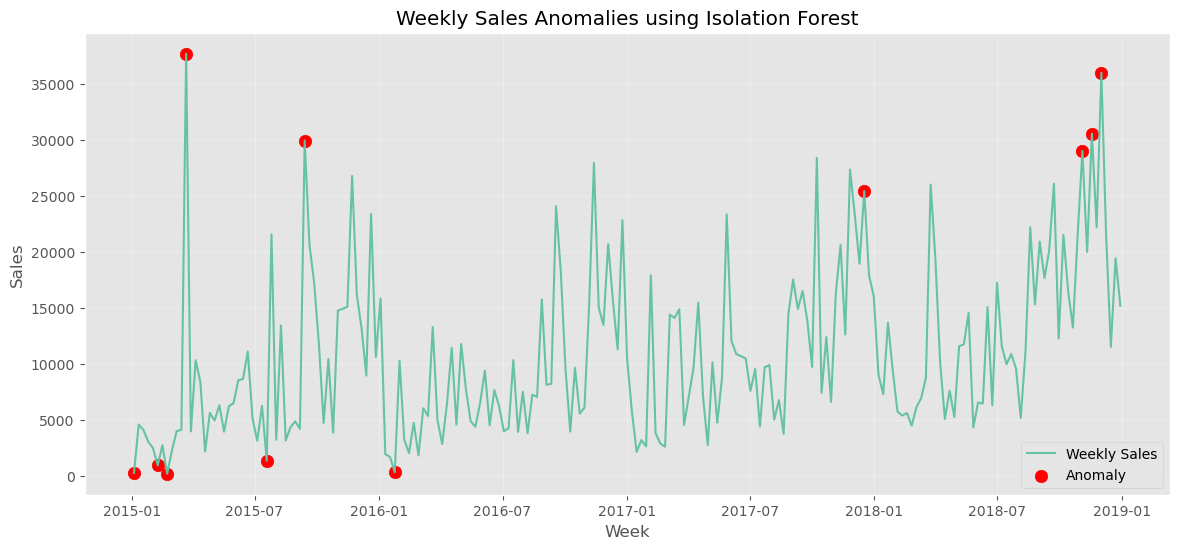

In [114]:
plt.figure(figsize=(14,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales"

)

plt.scatter(

    iso_anomalies["Order Date"],

    iso_anomalies["Sales"],

    color="red",

    s=80,

    label="Anomaly"

)

plt.title("Weekly Sales Anomalies using Isolation Forest")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "charts/isolation_forest_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Isolation Forest model identifies several weeks with unusually high or unusually low sales compared to the normal weekly sales pattern. These observations represent potential anomalies that may require further business investigation.

## Z-Score Based Detection

A rolling mean and rolling standard deviation are calculated.

A week is considered anomalous if its sales deviate by more than two standard deviations from the rolling average.

In [115]:
weekly_sales["Rolling Mean"] = (

    weekly_sales["Sales"]

    .rolling(

        window=8,

        center=True

    )

    .mean()

)

In [116]:
weekly_sales["Rolling Std"] = (

    weekly_sales["Sales"]

    .rolling(

        window=8,

        center=True

    )

    .std()

)

In [117]:
weekly_sales["Rolling Z"] = (

    weekly_sales["Sales"]

    -

    weekly_sales["Rolling Mean"]

) / weekly_sales["Rolling Std"]

In [118]:
weekly_sales["Z_Anomaly"] = (

    weekly_sales["Rolling Z"]

    .abs()

    >

    2

)

In [119]:
z_anomalies = weekly_sales[

    weekly_sales["Z_Anomaly"]

]

z_anomalies

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Rolling Z,Z_Anomaly
11,2015-03-22,37703.665,Anomaly,8896.190250,12079.340151,2.384855,True
29,2015-07-26,21590.080,Normal,7183.553750,6897.327905,2.088711,True
63,2016-03-20,13310.136,Normal,5712.780425,3439.251848,2.209014,True
109,2017-02-05,17926.368,Normal,5141.228750,5284.147247,2.419527,True
125,2017-05-28,23367.662,Normal,10442.132500,6138.903372,2.105511,True
144,2017-10-08,28412.098,Normal,13742.872737,6891.136042,2.128709,True


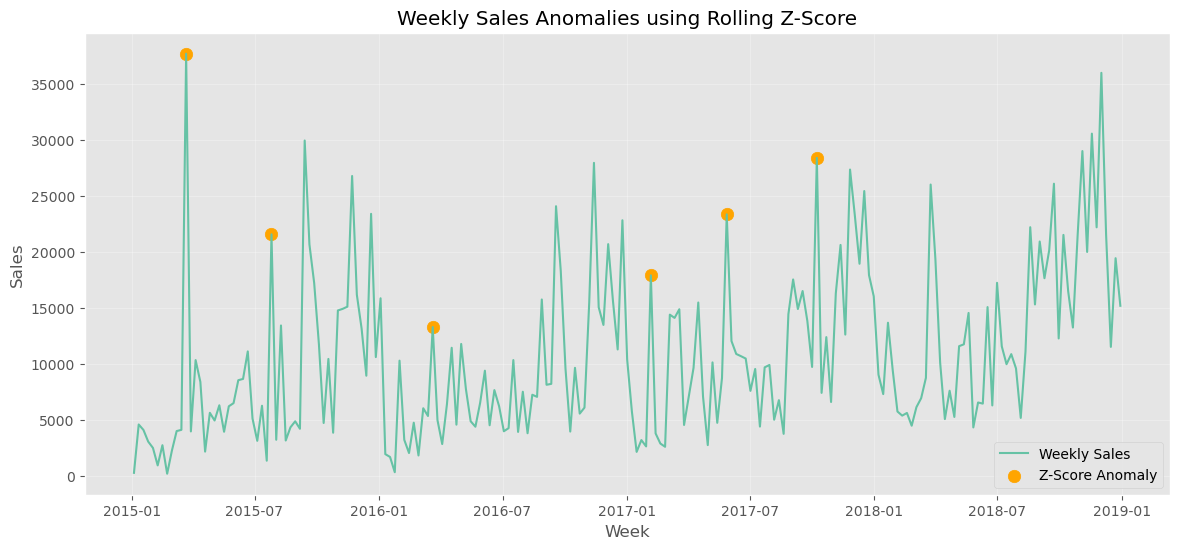

In [120]:
plt.figure(figsize=(14,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales"

)

plt.scatter(

    z_anomalies["Order Date"],

    z_anomalies["Sales"],

    color="orange",

    s=80,

    label="Z-Score Anomaly"

)

plt.title("Weekly Sales Anomalies using Rolling Z-Score")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The rolling Z-Score method identifies extreme sales values based on statistical deviation from recent sales behaviour. Compared with Isolation Forest, this method focuses on local variations within the time series.

In [121]:
comparison = weekly_sales.copy()

comparison["Isolation Forest"] = (

    comparison["Anomaly"] == "Anomaly"

)

comparison["Z-Score"] = comparison["Z_Anomaly"]

comparison[
    [

        "Order Date",

        "Sales",

        "Isolation Forest",

        "Z-Score"

    ]

]

,Order Date,Sales,Isolation Forest,Z-Score
0,2015-01-04,304.5080,True,False
1,2015-01-11,4619.1080,False,False
2,2015-01-18,4130.5330,False,False
3,2015-01-25,3092.5440,False,False
4,2015-02-01,2527.9140,False,False
...,...,...,...,...
204,2018-12-02,35998.9000,True,False
205,2018-12-09,21537.2410,False,False
206,2018-12-16,11542.8340,False,False
207,2018-12-23,19457.0680,False,False


In [122]:
print("Isolation Forest Anomalies :", len(iso_anomalies))

print("Z-Score Anomalies :", len(z_anomalies))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 6


## Possible Business Explanations for Detected Anomalies

The detected anomalies may be caused by different business events:

- Extremely high sales during November or December may correspond to festive shopping seasons, year-end promotions, or holiday discounts.
- Sudden sales spikes may result from successful marketing campaigns, bulk corporate purchases, or new product launches.
- Extremely low sales weeks may be caused by seasonal demand fluctuations, inventory shortages, holidays, or temporary supply chain disruptions.
- Unexpected sales changes may also occur due to pricing changes, competitor activities, or operational issues.

These anomalies should be investigated further before making strategic business decisions.

## Comparison of Isolation Forest and Z-Score Detection

Isolation Forest detected **11 anomalous weeks**, whereas the Rolling Z-Score method detected **6 anomalous weeks**.

Isolation Forest identified more anomalies because it uses a machine learning approach that isolates unusual observations without assuming a specific statistical distribution.

The Rolling Z-Score method is more conservative and only flags observations that deviate significantly from the local rolling average.

Some anomalies were detected by both methods, indicating strong evidence of unusual sales behavior, while others were detected only by Isolation Forest, suggesting subtle patterns that the statistical method could not identify.

## Business Insight

The anomaly detection analysis highlights several weeks with unusually high or unusually low sales.

These abnormal weeks may correspond to promotional campaigns, festive shopping seasons, inventory shortages, or unexpected market events.

Monitoring these anomalies helps businesses understand exceptional sales behavior, improve forecasting accuracy, and identify opportunities for operational improvements.

## Task 5 Conclusion

Two anomaly detection techniques were applied to weekly sales data.

- Isolation Forest detected 11 anomalies.
- Rolling Z-Score detected 6 anomalies.

Isolation Forest proved to be more sensitive in identifying unusual sales patterns, whereas the Rolling Z-Score method focused on larger statistical deviations.

Using both techniques together provides a more comprehensive understanding of abnormal sales behavior and supports better business decision-making.

# Task 6 : Product Demand Segmentation using Clustering

## Objective

The objective of this task is to segment product sub-categories based on their sales behavior.

Instead of forecasting sales, clustering groups products with similar demand patterns.

The following features are used for segmentation:

- Total Sales Volume
- Year-over-Year Sales Growth Rate
- Sales Volatility
- Average Order Value

K-Means Clustering is applied to identify groups of products with similar demand characteristics.

The Elbow Method is used to determine the optimal number of clusters.

In [123]:
from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

## Feature Engineering

Product demand is analyzed at the Sub-Category level.

Several business-oriented features are created to describe the demand behavior of each product group.

In [124]:
sales_volume = (

    df.groupby("Sub-Category")["Sales"]

    .sum()

    .rename("Total Sales")

)

In [125]:
average_order = (

    df.groupby("Sub-Category")["Sales"]

    .mean()

    .rename("Average Order Value")

)

In [126]:
monthly_sales = (

    df.groupby(

        [

            "Sub-Category",

            pd.Grouper(

                key="Order Date",

                freq="ME"

            )

        ]

    )["Sales"]

    .sum()

    .reset_index()

)

In [127]:
volatility = (

    monthly_sales

    .groupby("Sub-Category")["Sales"]

    .std()

    .rename("Sales Volatility")

)

In [128]:
yearly_sales = (

    df.groupby(

        [

            "Sub-Category",

            "Year"

        ]

    )["Sales"]

    .sum()

    .reset_index()

)

In [129]:
yearly_sales["Growth Rate"] = (

    yearly_sales

    .groupby("Sub-Category")["Sales"]

    .pct_change()

)

In [130]:
growth_rate = (

    yearly_sales

    .groupby("Sub-Category")["Growth Rate"]

    .mean()

    .fillna(0)

    .rename("Growth Rate")

)

In [131]:
cluster_data = pd.concat(

    [

        sales_volume,

        growth_rate,

        volatility,

        average_order

    ],

    axis=1

)

In [132]:
cluster_data

,Total Sales,Growth Rate,Sales Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [133]:
cluster_data.isnull().sum()

Total Sales            0
Growth Rate            0
Sales Volatility       0
Average Order Value    0
dtype: int64

In [134]:
cluster_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, Accessories to Tables
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Total Sales          17 non-null     float64
 1   Growth Rate          17 non-null     float64
 2   Sales Volatility     17 non-null     float64
 3   Average Order Value  17 non-null     float64
dtypes: float64(4)
memory usage: 680.0+ bytes


In [135]:
cluster_data.describe().round(2)

,Total Sales,Growth Rate,Sales Volatility,Average Order Value
count,17.00,17.00,17.00,17.00
mean,133031.58,0.33,2430.68,430.17
std,101630.99,0.46,1808.91,603.91
min,3001.96,-0.03,48.74,14.03
25%,46420.31,0.12,1024.82,65.03
50%,113813.20,0.17,2220.41,227.93
75%,200028.78,0.29,3848.22,503.60
max,327782.45,1.93,5603.55,2215.88


## Feature Scaling

Since all features have different ranges, they are standardized before applying K-Means clustering.

Standardization ensures that each feature contributes equally during distance calculations.

In [136]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_data)

scaled_features.shape

(17, 4)

## Finding the Optimal Number of Clusters

The Elbow Method helps determine the optimal number of clusters by measuring the Within Cluster Sum of Squares (WCSS).

The point where the curve begins to flatten is considered the optimal K.

In [137]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

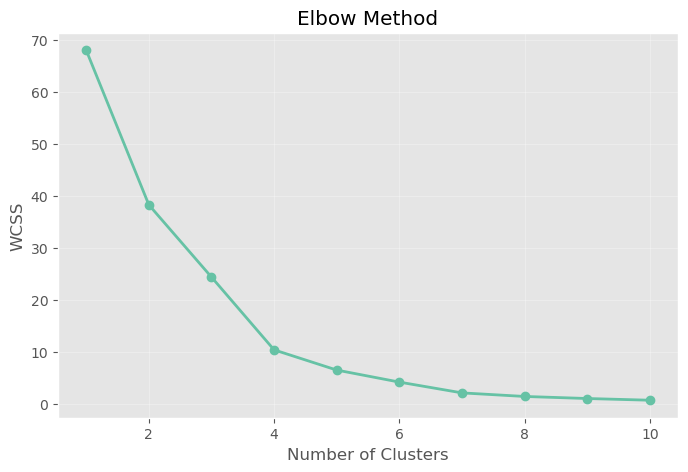

In [138]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(alpha=0.3)

plt.savefig(
    "charts/kmeans_elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The elbow point is observed at **K = 4**, indicating that four clusters provide a suitable balance between model simplicity and clustering quality.

## K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is chosen as K = 4.

The K-Means algorithm groups similar product sub-categories based on:

- Total Sales
- Growth Rate
- Sales Volatility
- Average Order Value

In [139]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_data.head()

,Total Sales,Growth Rate,Sales Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1


In [140]:
cluster_data["Cluster"].value_counts().sort_index()

Cluster
0    2
1    8
2    6
3    1
Name: count, dtype: int64

In [141]:
cluster_data.sort_values("Cluster")

,Total Sales,Growth Rate,Sales Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0
Machines,189238.6310,0.080060,5603.554747,1645.553313,0
Fasteners,3001.9600,0.157034,48.742229,14.027850,1
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1
Paper,76828.3040,0.254131,1024.824982,57.420257,1
Furnishings,89212.0180,0.287889,1360.017867,95.823865,1


In [142]:
cluster_summary = (

    cluster_data

    .groupby("Cluster")

    .mean()

    .round(2)

)

cluster_summary

,Total Sales,Growth Rate,Sales Volatility,Average Order Value
Cluster,,,,
0,167743.36,0.46,5552.16,1930.72
1,55331.88,0.20,907.22,129.05
2,239495.78,0.18,3489.06,361.13
3,46420.31,1.93,2025.09,252.28


In [143]:
cluster_names = {
    0: "Premium High Value Products",
    1: "Low Volume Stable Products",
    2: "High Demand Core Products",
    3: "Emerging Growth Products"
}

cluster_data["Demand Segment"] = cluster_data["Cluster"].map(cluster_names)

cluster_data

,Total Sales,Growth Rate,Sales Volatility,Average Order Value,Cluster,Demand Segment
Sub-Category,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,High Demand Core Products
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,Low Volume Stable Products
Art,26705.4100,0.166056,330.488343,34.019631,1,Low Volume Stable Products
Binders,200028.7850,0.218736,3848.223648,134.067550,2,High Demand Core Products
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,Low Volume Stable Products
Chairs,322822.7310,0.071358,4407.232960,531.833165,2,High Demand Core Products
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,Premium High Value Products
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,Low Volume Stable Products
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,Low Volume Stable Products


### Observation

The clustering algorithm successfully grouped product sub-categories into four distinct demand segments, each representing a different sales behaviour and business importance.

## Cluster Visualization using PCA

Since clustering was performed using four features, Principal Component Analysis (PCA) is used to reduce the data into two dimensions for visualization while preserving most of the variation.

In [144]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_data["PC1"] = pca_features[:,0]

cluster_data["PC2"] = pca_features[:,1]

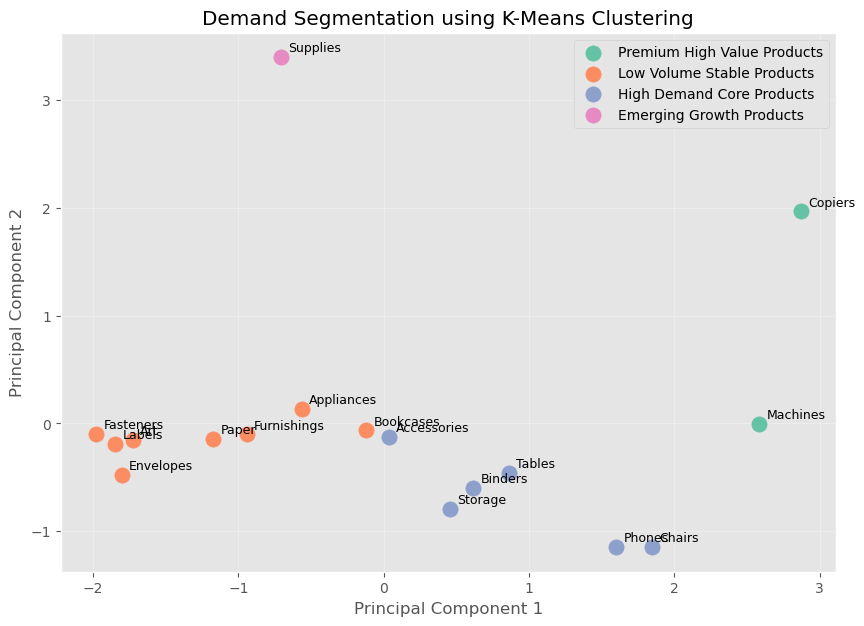

In [145]:
plt.figure(figsize=(10,7))

for cluster in sorted(cluster_data["Cluster"].unique()):

    temp = cluster_data[
        cluster_data["Cluster"] == cluster
    ]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=120,
        label=cluster_names[cluster]
    )

for subcategory in cluster_data.index:

    plt.text(
        cluster_data.loc[subcategory,"PC1"] + 0.05,
        cluster_data.loc[subcategory,"PC2"] + 0.05,
        subcategory,
        fontsize=9
    )

plt.title("Demand Segmentation using K-Means Clustering")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    "charts/product_demand_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The visualization shows clear separation between the identified product groups, indicating that the selected features successfully capture differences in demand behaviour across product sub-categories.

In [146]:
cluster_data[
    [
        "Total Sales",
        "Growth Rate",
        "Sales Volatility",
        "Average Order Value",
        "Demand Segment"
    ]
].sort_values("Demand Segment")

,Total Sales,Growth Rate,Sales Volatility,Average Order Value,Demand Segment
Sub-Category,,,,,
Supplies,46420.3080,1.928448,2025.094139,252.284283,Emerging Growth Products
Accessories,164186.7000,0.376381,2579.994809,217.178175,High Demand Core Products
Storage,219343.3920,0.131799,2822.084310,263.633885,High Demand Core Products
Phones,327782.4480,0.123409,4052.718221,374.180877,High Demand Core Products
Chairs,322822.7310,0.071358,4407.232960,531.833165,High Demand Core Products
Tables,202810.6280,0.164107,3224.082504,645.893720,High Demand Core Products
Binders,200028.7850,0.218736,3848.223648,134.067550,High Demand Core Products
Envelopes,16128.0460,-0.027666,228.218688,65.032444,Low Volume Stable Products
Furnishings,89212.0180,0.287889,1360.017867,95.823865,Low Volume Stable Products


## Business Insights

### Premium High Value Products
These products generate high revenue and have a high average order value. Although demand fluctuates, they contribute significantly to overall sales and should always remain in stock.

### High Demand Core Products
These products consistently contribute the highest sales volume. They should receive the highest inventory priority and frequent replenishment.

### Low Volume Stable Products
These products experience relatively stable demand with lower sales volumes. Moderate inventory levels are sufficient to avoid overstocking.

### Emerging Growth Products
These products exhibit the fastest sales growth. Increasing inventory and closely monitoring demand can help capitalize on future growth opportunities.

## Recommended Stocking Strategy

• Premium High Value Products:
Maintain sufficient stock with regular monitoring due to their high contribution to revenue.

• High Demand Core Products:
Prioritize inventory replenishment and maintain higher safety stock to prevent stock-outs.

• Low Volume Stable Products:
Maintain moderate inventory levels and replenish only when necessary.

• Emerging Growth Products:
Gradually increase inventory while continuously monitoring demand trends, as these products have strong future growth potential.

# Task 6 Summary

Product sub-categories were successfully segmented into meaningful demand groups using K-Means clustering. The analysis identified distinct product behaviours based on sales performance, growth, volatility, and average order value. These demand segments provide valuable guidance for inventory planning, procurement, and warehouse management by enabling tailored stocking strategies for different product groups.

# Project Conclusion

This project successfully developed an end-to-end sales forecasting and demand intelligence system using historical retail sales data. The analysis combined exploratory data analysis, forecasting, anomaly detection, demand segmentation, and dashboard development to generate actionable business insights.

The selected forecasting model was deployed through an interactive Streamlit dashboard, enabling business users to monitor sales trends, explore forecasts, detect anomalies, and understand product demand segments without requiring technical expertise.

Overall, the project demonstrates how data analytics and machine learning can support data-driven decision-making in retail inventory planning and supply chain management.